# GSE150115 初步分析
结肠组织样本，3个样本进行分析（排除两个细胞数量太少的样本）  
3UC
- UC8-UC10

In [1]:
import scanpy as sc
import omicverse as ov
ov.plot_set()
ov.settings.cpu_gpu_mixed_init()

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 5060 Ti
    • Total memory: 15.9 GB
    • Compute capability: 12.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

CPU-GPU mixed mode activated


## 读取表达矩阵类型数据

In [2]:
import pandas as pd
import os

data_dir = "/mnt/e/UC/scRNA-seq_RAW/1_GSE150115"
adatas = []

for file in sorted(os.listdir(data_dir)):
    if not file.endswith(".txt"):
        continue

    path = os.path.join(data_dir, file)
    sample = os.path.splitext(file)[0]

    df = pd.read_csv(path, sep="\t", index_col=0)
    ad = sc.AnnData(df.T)
    sc.pp.filter_cells(ad, min_genes=200)
    sc.pp.filter_genes(ad, min_cells=3)

    ad.obs['GSM_id'] = sample
    ad.obs_names = [f"{sample}_{x}" for x in ad.obs_names]

    adatas.append(ad)

adata = sc.concat(adatas, merge='same')

filtered out 321 cells that have less than 200 genes expressed
filtered out 6245 genes that are detected in less than 3 cells
filtered out 2682 cells that have less than 200 genes expressed
filtered out 8196 genes that are detected in less than 3 cells
filtered out 1138 cells that have less than 200 genes expressed
filtered out 9477 genes that are detected in less than 3 cells


In [3]:
adata

AnnData object with n_obs × n_vars = 7859 × 14605
    obs: 'n_genes', 'GSM_id'

In [4]:
adata.obs['GSM_id'].value_counts()

GSM_id
GSM4523789_UC8     3679
GSM4523791_UC10    2862
GSM4523790_UC9     1318
Name: count, dtype: int64

In [5]:
adata.obs['GSM'] = adata.obs['GSM_id'].str.split("_").str[0]  
adata.obs['id']  = adata.obs['GSM_id'].str.split("_").str[1]  

## 预处理步骤
- QC: mito<0.2, UMI>500, genes>250, 去除双细胞
- HVG: Pearson方法，2000个
- PCA: 50个PCs
- neighbors: 最邻近数15，使用前50PCs
- leiden: resolution0.7

In [6]:
# QC
adata=ov.pp.qc(adata,
               tresh={'mito_perc': 0.2, 'nUMIs': 500, 'detected_genes': 250},
               doublets_method='scrublet',
               batch_key=None)

# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=2000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.7)

⚙️ Using CPU/GPU mixed mode for QC...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    |||||------------------------- 3075/16311 MiB (18.9%)

🔍 Quality Control Analysis (CPU-GPU Mixed):
   Dataset shape: 7,859 cells × 14,605 genes
   QC mode: seurat
   Doublet detection: scrublet
   Mitochondrial genes: MT-

📊 Step 1: Calculating QC Metrics
   Mitochondrial genes (prefix 'MT-'): 24 found
   ✓ QC metrics calculated:
     • Mean nUMIs: 2131 (range: 275-42452)
     • Mean genes: 925 (range: 160-7664)
     • Mean mitochondrial %: 0.0% (max: 0.3%)

🔧 Step 2: Quality Filtering (SEURAT)
   Thresholds: mito≤0.2, nUMIs≥500, genes≥250
   📊 Seurat Filter Results:
     • nUMIs filter (≥500): 262 cells failed (3.3%)
     • Genes filter (≥250): 502 cells failed (6.4%)
     • Mitochondrial filter (≤0.2): 0 cells failed (0.0%)
   ✓ Combined QC filters: 614 cells removed (7.8%)

🎯 Step 3: Final Filtering
   Parameters: min_genes=200, min_cells=3
   Ratios: max_genes_ratio=1, max_cel

In [7]:
adata

AnnData object with n_obs × n_vars = 7244 × 2000
    obs: 'n_genes', 'GSM_id', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'mt', 'n_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', 'log1p', 'hvg', 'pca', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'scaled|original|X_pca', 'X_umap'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled'
    obsp: 'distances', 'connectivities'

In [8]:
adata.obs['id'].value_counts()

id
UC8     3575
UC10    2709
UC9      960
Name: count, dtype: int64

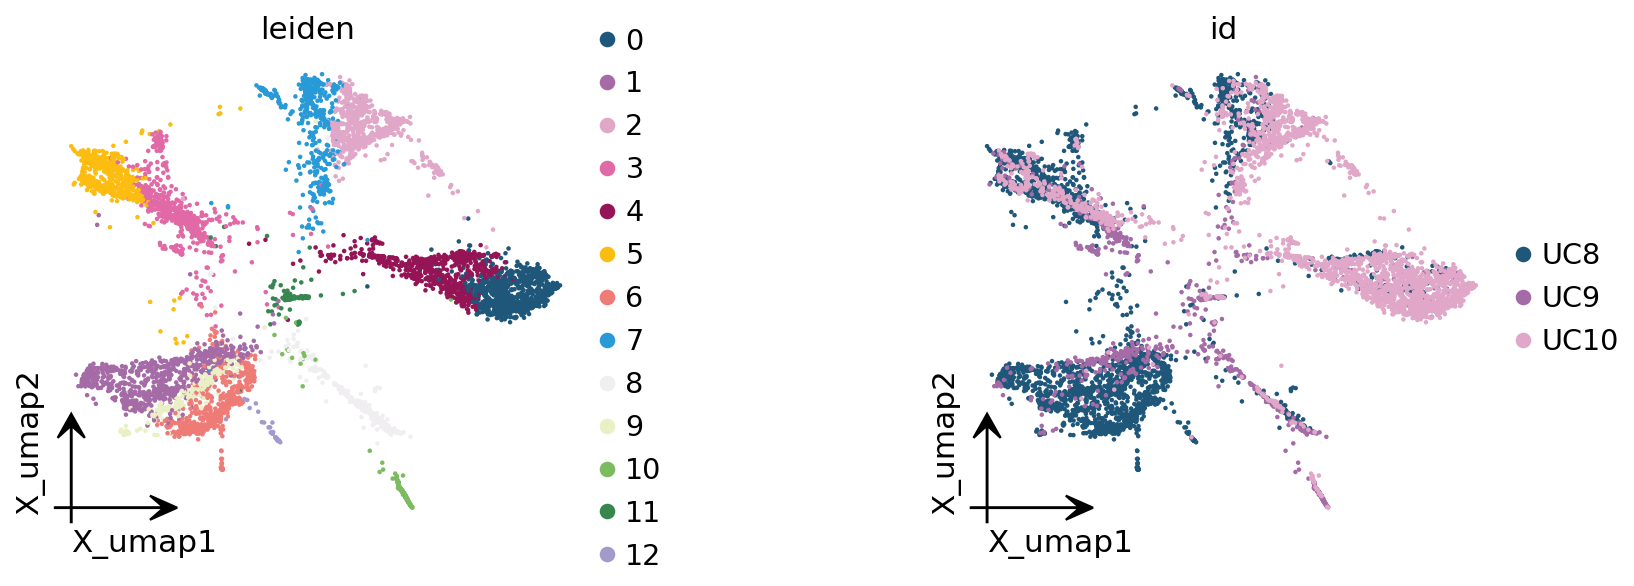

In [9]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'id'],
                frameon='small',
                wspace=0.5)

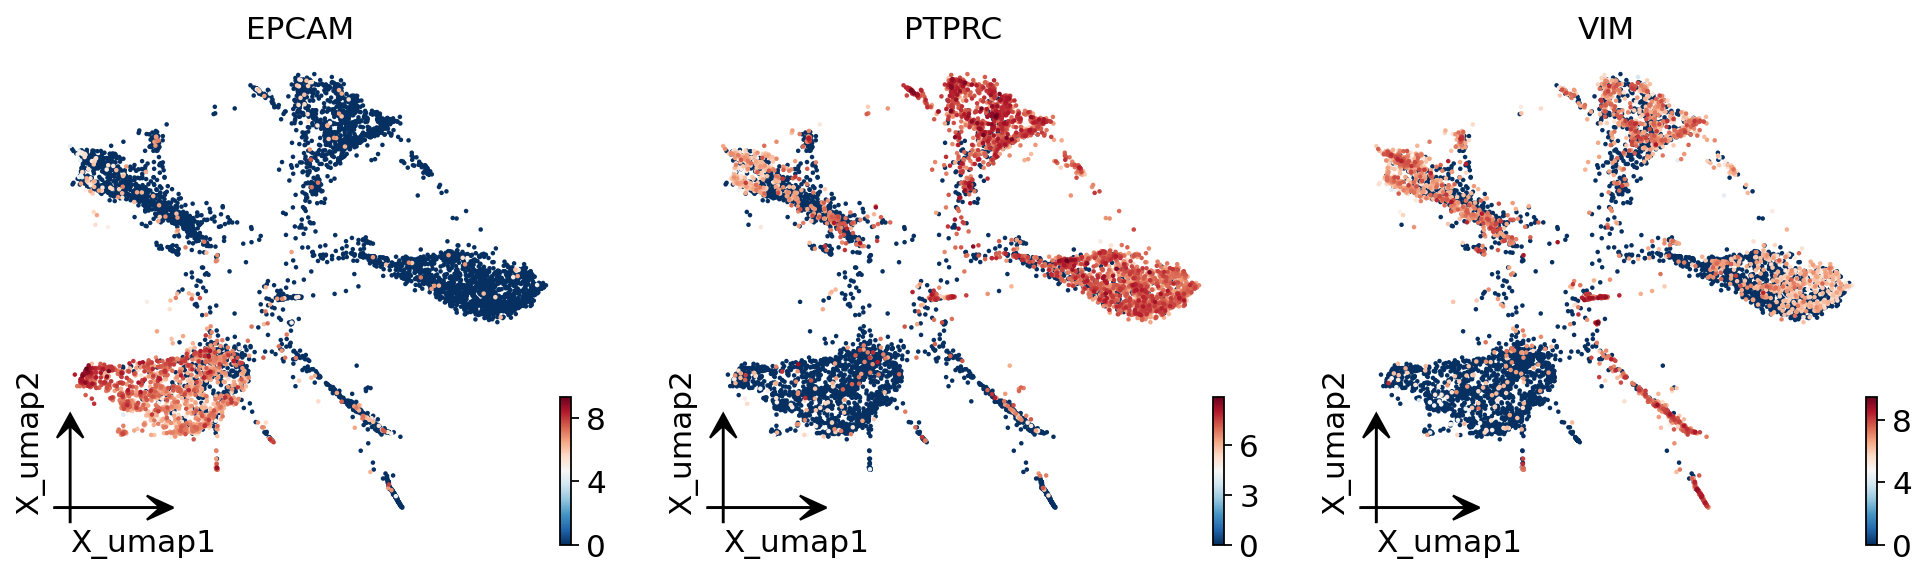

In [10]:
# 粗略查看上皮、免疫、基质细胞
ov.pl.embedding(adata,
                basis='X_umap',
                color=['EPCAM', 'PTPRC', 'VIM'],
                frameon='small')

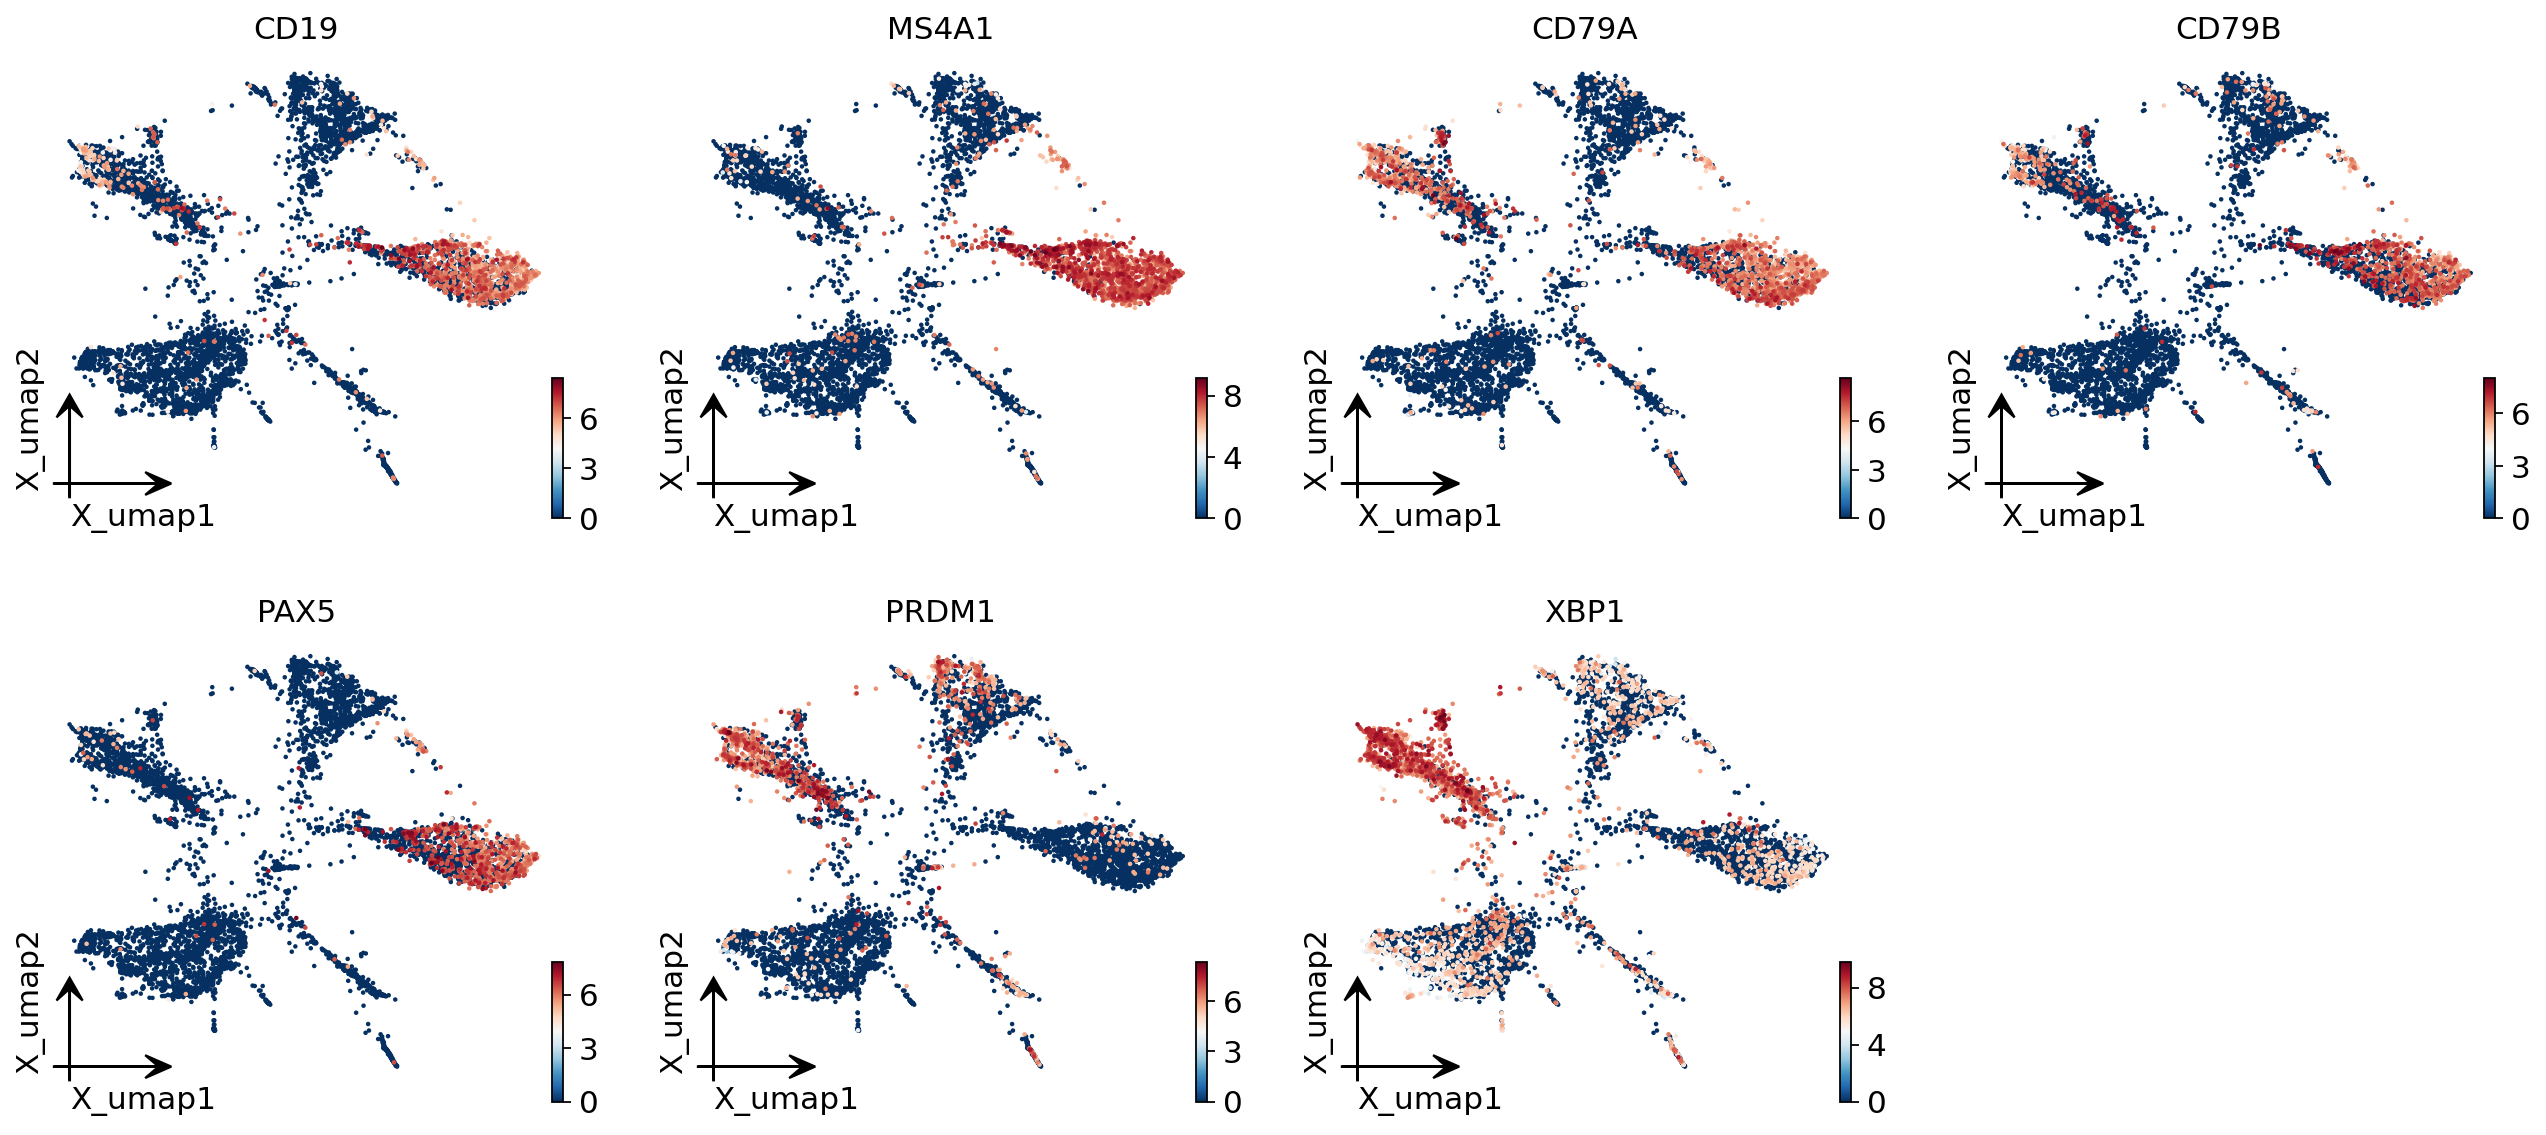

In [12]:
# 查看B细胞和浆细胞
ov.pl.embedding(adata,
                basis='X_umap',
                color=['CD19', 'MS4A1', 'CD79A', 'CD79B', 'PAX5', 'PRDM1', 'XBP1'],
                frameon='small')

## GPT自动注释

In [13]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:07)


{'0': ['LAPTM5',
  'CXCR4',
  'CD74',
  'BANK1',
  'HLA-DRA',
  'HLA-DPA1',
  'CD83',
  'HLA-DPB1',
  'HLA-DRB1',
  'MS4A1'],
 '1': ['MT-CO3',
  'MT-CO2',
  'KRT19',
  'MUC4',
  'EPCAM',
  'AGR2',
  'CEACAM5',
  'LCN2',
  'S100A6',
  'PIGR'],
 '10': ['PDGFRB',
  'CALD1',
  'COL4A1',
  'COL3A1',
  'IGFBP7',
  'COL4A2',
  'COL1A2',
  'COL6A2',
  'SPARC',
  'A2M'],
 '11': ['FTL',
  'TYROBP',
  'FTH1',
  'SOD2',
  'SAT1',
  'VIM',
  'LYZ',
  'PSAP',
  'IL1B',
  'S100A9'],
 '12': ['TP53I3',
  'TPM1',
  'PTPN18',
  'ALOX5',
  'AVIL',
  'RASSF6',
  'MALAT1',
  'BMX',
  'IL17RB',
  'LRMP'],
 '2': ['TRBC2',
  'CD3D',
  'FYB',
  'PABPC1',
  'SPOCK2',
  'SRGN',
  'IL7R',
  'ETS1',
  'TNFAIP3',
  'PTPRC'],
 '3': ['IGHG1',
  'IGKC',
  'HSP90B1',
  'HERPUD1',
  'MZB1',
  'IGHG3',
  'SSR4',
  'IGHA1',
  'IGJ',
  'XBP1'],
 '4': ['MTRNR2L1',
  'IGHM',
  'CD74',
  'BANK1',
  'FCRL1',
  'CD22',
  'HLA-DRA',
  'HLA-DPA1',
  'HLA-DRB1',
  'MS4A1'],
 '5': ['SEC11C',
  'PRDX4',
  'HSP90B1',
  'HERPUD1',
  'M

In [14]:
os.environ['AGI_API_KEY'] = 'sk-ff0dc715f640466393e6aa71c9da6848'
result = ov.single.gptcelltype(all_markers,
                               tissuename='colon',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

Note: AGI API key found: returning the cell type annotations.
Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.


{'0': 'B cells',
 '1': 'Epithelial cells',
 '10': 'Fibroblasts',
 '11': 'Macrophages',
 '12': 'Smooth muscle cells',
 '2': 'T cells',
 '3': 'Plasma cells',
 '4': 'B cells and plasma cells',
 '5': 'Plasma cells',
 '6': 'Enterocytes',
 '7': 'T cells',
 '8': 'Endothelial cells',
 '9': 'Goblet cells'}

In [15]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

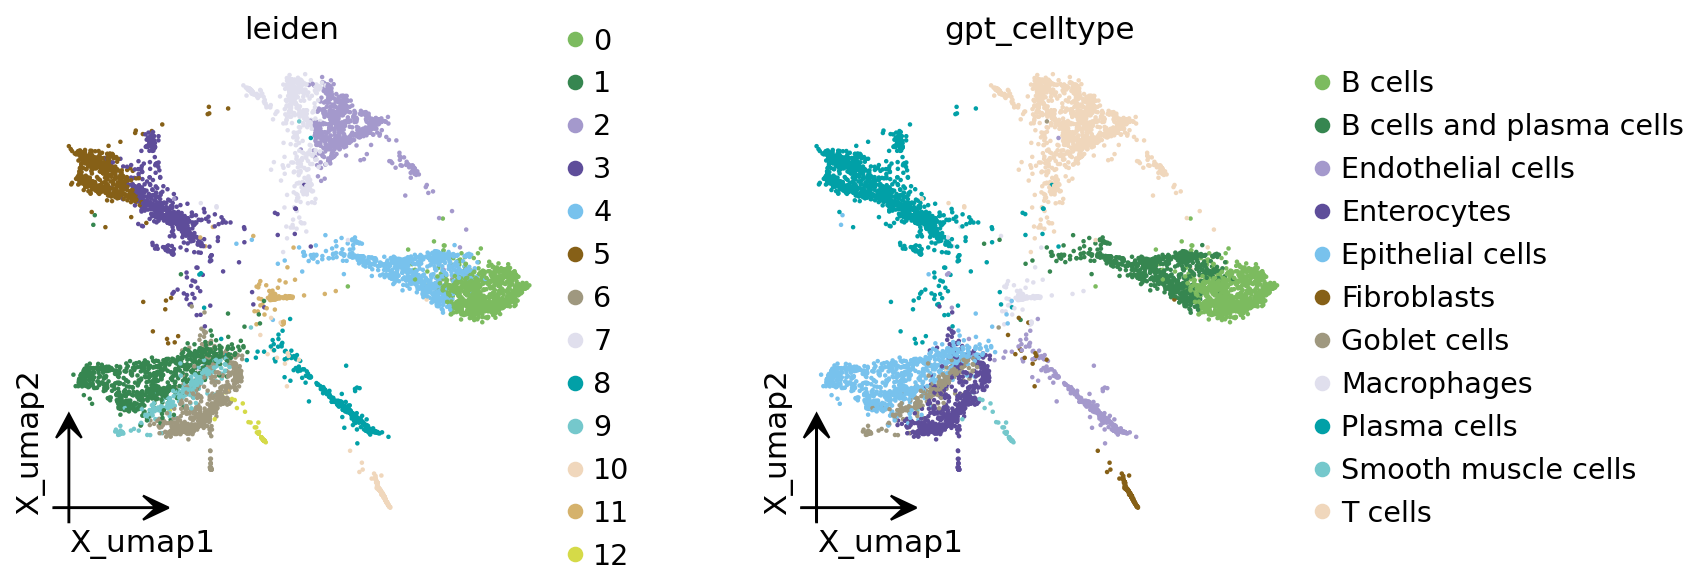

In [16]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

# 总结
疑问：
- 有一团很可疑的浆细胞

优点：
- gpt识别出了杯状细胞